In [117]:
from keras.preprocessing.image import load_img, array_to_img
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras import regularizers
from keras.optimizers import Adam
from skimage import io
from skimage.transform import resize
import glob
from tensorflow.keras.applications import DenseNet121
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import cv2

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#Functions to read in data and resize images

def read_image_data(img_dir = "../data/archive/chest_xray/",dataset='train'):
    path_norm_images = img_dir+dataset+"/NORMAL"
    path_sick_images = img_dir+dataset+"/PNEUMONIA"

    #Load all jpeg files
    norm_files = glob.glob(f'{path_norm_images}/*jpeg')
    sick_files = glob.glob(f'{path_sick_images}/*jpeg')

    #Read images as a list of arrays
    norm_images = [io.imread(image_file, as_gray=True) for image_file in norm_files]
    sick_images = [io.imread(image_file, as_gray=True) for image_file in sick_files]

    return norm_images, sick_images

def resize_images(images,image_width=128,image_height=128):
    resized = [resize(image,(image_width,image_height)) for image in images]
    
    return resized

In [3]:
#read in training and test data
X_train_norm_images, X_train_sick_images = read_image_data(dataset='train')
X_test_norm_images, X_test_sick_images = read_image_data(dataset='test')

#resize images
X_train_norm_resize, X_train_sick_resize, X_test_norm_resize, X_test_sick_resize = map(resize_images,[X_train_norm_images, X_train_sick_images, X_test_norm_images, X_test_sick_images])


In [4]:
# Convert to numpy arrays
X_train_norm_np, X_train_sick_np, X_test_norm_np, X_test_sick_np = map(np.array,[X_train_norm_resize, X_train_sick_resize, X_test_norm_resize, X_test_sick_resize])

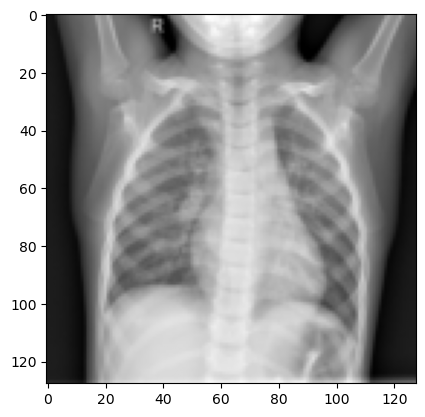

In [5]:
#Visualize 1 normal xray from the the training set
plt.imshow(X_train_norm_np[0],cmap='gray')
plt.show()

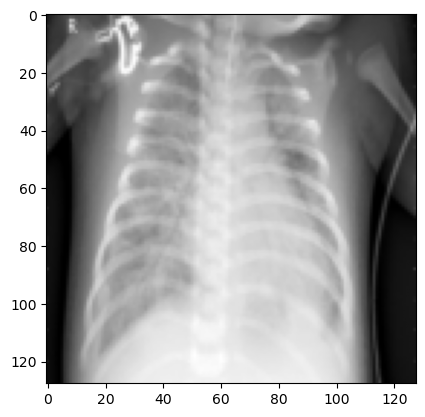

In [6]:
#Visualize 1 Pneumonia xray from the the training set
plt.imshow(X_train_sick_np[0],cmap='gray')
plt.show()

In [7]:
#Concatenate into X_train and X_test
X_train = np.concatenate( (X_train_norm_np , X_train_sick_np) )
X_test = np.concatenate( (X_test_norm_np, X_test_sick_np) )

In [8]:
#Form y_train and y_test arrays
y_train = np.concatenate( (np.zeros((len(X_train_norm_np),)) , np.ones((len(X_train_sick_np),))) )
y_test = np.concatenate( (np.zeros((len(X_test_norm_np),)) , np.ones((len(X_test_sick_np),))) )

In [9]:
X_train.shape

(5216, 128, 128)

In [10]:
X_test.shape

(624, 128, 128)

As a first pass, I'll try a simple neural network with two dense layers. Preprocessing is accomplished in the form of data augmentation layers to apply perturbations to the input images to reduce overfitting.

In [24]:
first_model = Sequential()
first_model.add(Input(shape=(128,128,1)))
#apply data augmentation to apply various perturbations to the training set images
first_model.add(layers.RandomFlip("horizontal")) #Randomly flip some images horizontally. Shouldn't flip vertically for anatomical applications
first_model.add(layers.RandomRotation(0.02)) # random rotation in a range of +/-2%
first_model.add(layers.RandomZoom(0.1)) # random zoom
first_model.add(layers.RandomContrast(0.1)) # Random contrast

first_model.add(layers.Flatten())
first_model.add(Dense(512,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
first_model.add(Dropout(0.2))
first_model.add(Dense(512,activation='relu'))
first_model.add(Dense(1,activation='sigmoid'))

Our main model metric will be recall since we want to make sure we maximize the number of true positives (sick patients) we classify correctly.

In [25]:
optimizer = Adam(learning_rate=0.0001)
first_model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['recall'])

In [26]:
first_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 128, 128, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 128, 128, 1)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,652,289 (33.01 MB)

 Trainable params: 8,652,289 (33.01 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
first_history = first_model.fit(X_train, y_train, epochs=20,validation_data=(X_test,y_test))

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - loss: 1.2221 - recall: 0.9414 - val_loss: 1.1880 - val_recall: 0.9949
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 0.8377 - recall: 0.9445 - val_loss: 0.9626 - val_recall: 0.9538
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - loss: 0.7049 - recall: 0.9432 - val_loss: 0.8715 - val_recall: 0.9487
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - loss: 0.5880 - recall: 0.9502 - val_loss: 0.8569 - val_recall: 0.9462
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - loss: 0.5343 - recall: 0.9461 - val_loss: 0.7272 - val_recall: 0.9205
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - loss: 0.4817 - recall: 0.9520 - val_loss: 0.7062 - val_recall: 0.9513
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 0.4266 - recall: 0.9548 - val_loss: 0.7667 - val_recall: 0.9615
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - loss: 0.4033 - recall: 0.9543 - val_loss: 0.7861 - val_recall:

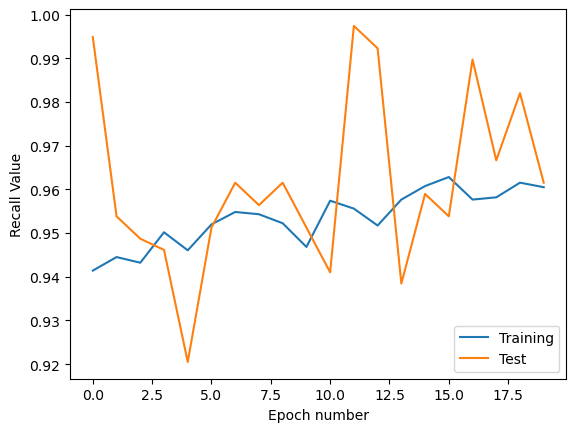

In [28]:
plt.plot(first_history.history['recall'],label="Training")
plt.plot(first_history.history['val_recall'],label="Test")
plt.ylabel("Recall Value")
plt.xlabel("Epoch number")
plt.legend()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


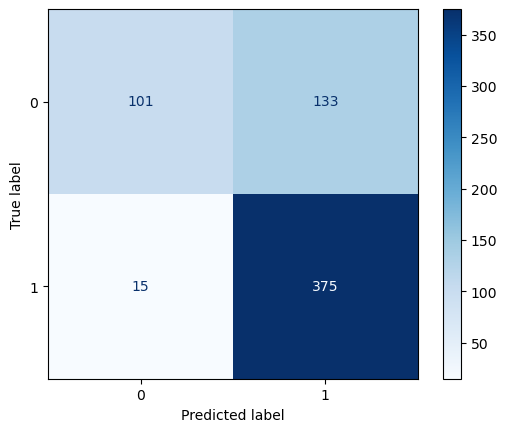

In [97]:
#Make predictions
threshold = 0.5
y_pred = (first_model.predict(X_test) >= threshold).astype(int)
#make a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Test set results for the first model
Recall = 96%

Precision = 74%

specificity = 43%

accuracy = 76%

The high recall with relatively low precision and specificity means we are predicting Pneumonia too often and the false positive rate is high. This is consistent with the imbalance of the training set, being skewed towards positive cases. The learning curve for the test set is quite unstable. The minor increase in the training curve suggests that the model isn't improving and we likely have reached the limit of the current model's architecture. Some tuning could help marginally but let's try a more complex model architecture instead. A convolutional neural captures the spatial relationship between pixels, allowing it to detect edges, textures, opacity, etc.

# Try a custom Convolutional Neural Network

In [22]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [29]:
X_train.shape

(5216, 128, 128, 1)

In [88]:
#Predefine our data augmentation layer
data_augmentation = tf.keras.Sequential([
  # Subtle rotations only (misalignment simulation)
  layers.RandomRotation(0.01), # ±1% of 2*pi
  
  # Horizontal flip is okay, but NO vertical flip for anatomy
  layers.RandomFlip("horizontal"), 
  
  # Crucial for X-rays: simulate different machine exposures
  #layers.RandomBrightness(factor=0.1), # ±10% brightness
  #layers.RandomContrast(factor=0.1),   # ±10% contrast
  
  #Brightness, contrast, and zoom changes may be preventing our model from learning from the training set

  # Small zooms for different patient distances
  layers.RandomZoom(0.05)
])

In [89]:
#Build our CNN
def build_xray_model(input_shape=(128, 128, 1)): #1 channel for grayscale images
    model = Sequential([
        layers.Input(shape=input_shape), 

        
        data_augmentation,
        layers.Reshape(input_shape),
        
        # --- Feature Extraction (Convolutional Layers) ---
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(), # Stabilizes the "jitter" in the plot
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # --- Classification (Dense Layers) ---
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.25), # Forces the model to generalize
        layers.Dense(1, activation='sigmoid') # Output: Probability 0 to 1
    ])
    
    return model

cnn_model = build_xray_model(input_shape=(128,128,1))
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy','Recall','Precision'])

In [90]:
#Account for class imbalance
#get unbalanced class weights of training data
total = len(y_train)
num_sick = y_train.sum()
num_norm = total - num_sick

# Standard balanced weight formula: Total / (Classes * Class_Count)
# This keeps the average weight around 1.0
#weight_0 = total / (2.0 * num_norm)
#weight_1 = total / (2.0 * num_sick)

#Aggressive weighting because the model started to always guess the majority class
weight_0 = 4.5
weight_1 = 1.0

class_weights = {0: weight_0, 1: weight_1}

In [91]:
#define callbacks to reduce learning rate when needed...
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', # Watch the orange line in my plot
    factor=0.2,           # Cut LR to 20% when it plateaus
    patience=2,           # Wait 2 epochs of no improvement before cutting
    min_lr=1e-6,          # Don't let it go below this
    verbose=1             # Prints a message when it happens
)
# and stop early if overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5, 
    restore_best_weights=True
)
cnn_history = cnn_model.fit(X_train, y_train, class_weight=class_weights, batch_size=64, epochs=50,validation_data=(X_test,y_test), callbacks=[reduce_lr, early_stop], shuffle=True)

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 511ms/step - Precision: 0.9706 - Recall: 0.8790 - accuracy: 0.8903 - loss: 0.8019 - val_Precision: 0.6250 - val_Recall: 1.0000 - val_accuracy: 0.6250 - val_loss: 22.3525 - learning_rate: 0.0010
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 495ms/step - Precision: 0.9862 - Recall: 0.9383 - accuracy: 0.9444 - loss: 0.2835 - val_Precision: 0.6250 - val_Recall: 1.0000 - val_accuracy: 0.6250 - val_loss: 29.5641 - learning_rate: 0.0010
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - Precision: 0.9827 - Recall: 0.9338 - accuracy: 0.9389 - loss: 0.2844
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 499ms/step - Precision: 0.9842 - Recall: 0.9332 - accuracy: 0.9392 - loss: 0.2731 - val_Precision: 0.6250 - val_Recall: 1.0000 - val_accuracy: 0.6250 - val_loss: 32.2510 - learning_rate: 0.0010
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 502ms/step - Precision: 0.9900 - Recall: 0.9468 - accuracy: 0

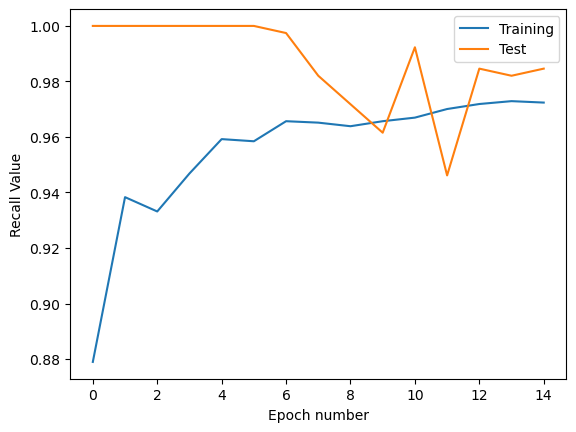

In [92]:
plt.plot(cnn_history.history['Recall'],label="Training")
plt.plot(cnn_history.history['val_Recall'],label="Test")
plt.ylabel("Recall Value")
plt.xlabel("Epoch number")
plt.legend()
plt.show()

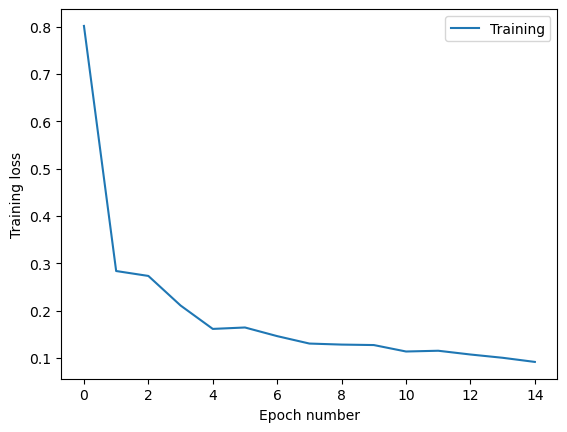

In [93]:
plt.plot(cnn_history.history['loss'],label="Training")
plt.ylabel("Training loss")
plt.xlabel("Epoch number")
plt.legend()
plt.show()

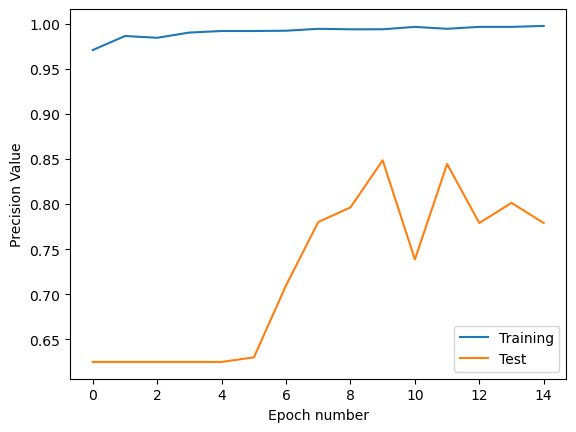

In [94]:
plt.plot(cnn_history.history['Precision'],label='Training')
plt.plot(cnn_history.history['val_Precision'],label='Test')
plt.ylabel("Precision Value")
plt.xlabel("Epoch number")
plt.legend()
plt.show()

In [95]:
#Make predictions
threshold = 0.5
y_pred = (cnn_model.predict(X_test) >= threshold).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


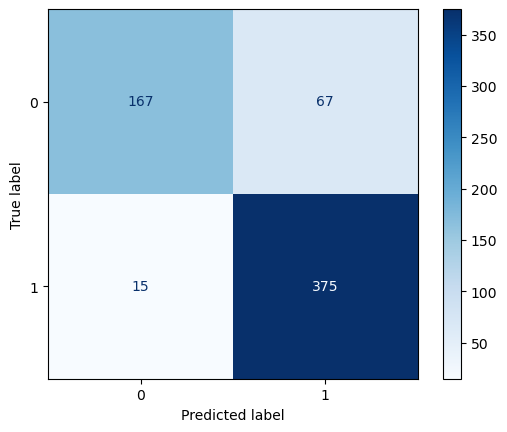

In [96]:
#make a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Test set results for custom CNN
recall = 96%

precision = 85%

specificity = 71%

accuracy = 87%

This is a significant improvement over the previous simple dense model. There is still room for improvement, since for medical applications we want to minimize the times we miss a case of pneumonia, as well as the times we falsely diagnose someone with the disease. We can move to a transfer learning model such as DenseNet121 implemented in Keras.

# Move to a pre-trained transfer learning model, DenseNet121

In [98]:
# 1. Load the pre-trained model (weights='imagenet')
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

base_model.trainable = False # Freeze the "brain" initially

DN_model = tf.keras.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(3, (3, 3), padding='same'), # Convert 1 channel to 3 for DenseNet
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

DN_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['recall','precision','accuracy'])

We will start the training with a few epochs with the DenseNet weights frozen

In [99]:
DN_history = DN_model.fit(X_train, y_train, class_weight=class_weights, epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 495ms/step - accuracy: 0.6123 - loss: 0.9904 - precision: 0.9364 - recall: 0.5130 - val_accuracy: 0.6603 - val_loss: 0.6155 - val_precision: 0.8803 - val_recall: 0.5282
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 490ms/step - accuracy: 0.7818 - loss: 0.7100 - precision: 0.9647 - recall: 0.7332 - val_accuracy: 0.8109 - val_loss: 0.4482 - val_precision: 0.8778 - val_recall: 0.8103
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 486ms/step - accuracy: 0.8551 - loss: 0.5647 - precision: 0.9739 - recall: 0.8271 - val_accuracy: 0.8253 - val_loss: 0.4098 - val_precision: 0.8787 - val_recall: 0.8359
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 485ms/step - accuracy: 0.8746 - loss: 0.4965 - precision: 0.9775 - recall: 0.8508 - val_accuracy: 0.8333 - val_loss: 0.3853 - val_precision: 0.8783 - val_recall: 0.8513
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 487ms/step - accuracy: 0.8878 - loss: 0.4517 - precision: 0.9793 - recall: 0.8674 - val_accuracy: 0.8397

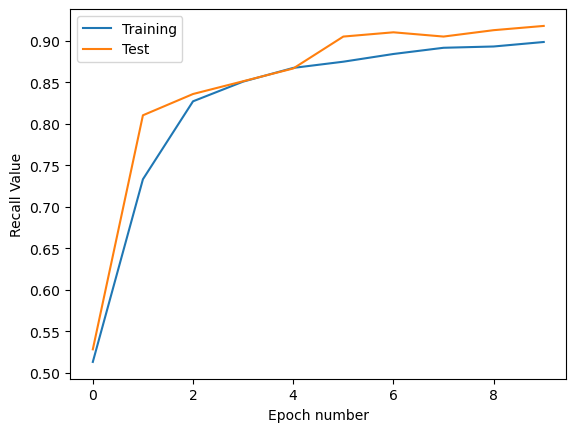

In [100]:
plt.plot(DN_history.history['recall'],label="Training")
plt.plot(DN_history.history['val_recall'],label="Test")
plt.ylabel("Recall Value")
plt.xlabel("Epoch number")
plt.legend()
plt.show()

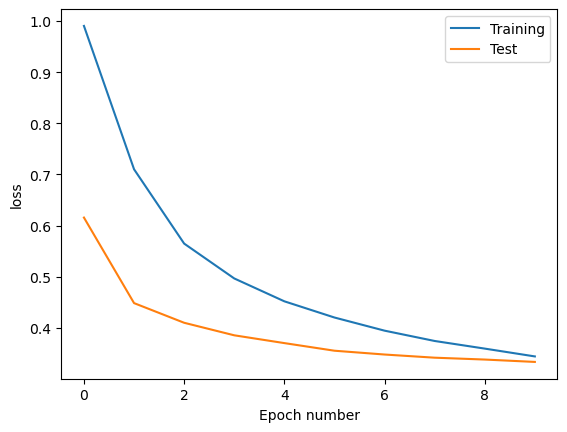

In [102]:
plt.plot(DN_history.history['loss'],label="Training")
plt.plot(DN_history.history['val_loss'],label="Test")
plt.ylabel("loss")
plt.xlabel("Epoch number")
plt.legend()
plt.show()

Then unfreeze the last the last 30 layers of the base model and train for a few more epochs

In [103]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

#Re-compile
DN_model.compile(optimizer=Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['recall','precision','accuracy'])

#Train for a few more epochs
DN_model.fit(X_train, y_train, class_weight=class_weights, epochs=5,validation_data=(X_test,y_test))

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 493ms/step - accuracy: 0.8742 - loss: 1.1915 - precision: 0.8601 - recall: 0.9920 - val_accuracy: 0.7949 - val_loss: 0.5397 - val_precision: 0.7599 - val_recall: 0.9821
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 479ms/step - accuracy: 0.9314 - loss: 0.5864 - precision: 0.9339 - recall: 0.9768 - val_accuracy: 0.8125 - val_loss: 0.5475 - val_precision: 0.7780 - val_recall: 0.9795
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 483ms/step - accuracy: 0.9446 - loss: 0.3880 - precision: 0.9616 - recall: 0.9639 - val_accuracy: 0.8333 - val_loss: 0.4940 - val_precision: 0.7992 - val_recall: 0.9795
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 514ms/step - accuracy: 0.9444 - loss: 0.3087 - precision: 0.9713 - recall: 0.9533 - val_accuracy: 0.8462 - val_loss: 0.4319 - val_precision: 0.8155 - val_recall: 0.9744
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 505ms/step - accuracy: 0.9454 - loss: 0.2682 - precision: 0.9792 - recall: 0.9466 - val_accuracy: 0.8622 - va

In [112]:
#Make predictions
threshold = 0.5
y_pred = (DN_model.predict(X_test) >= threshold).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step


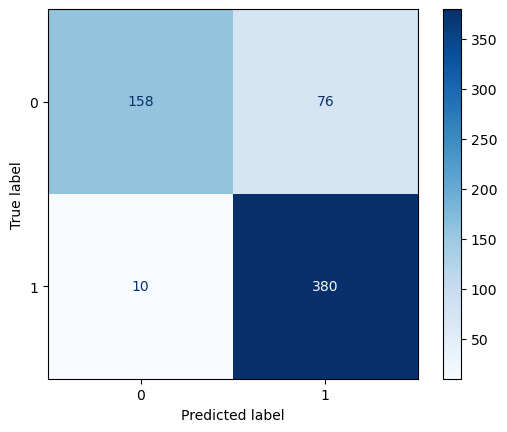

In [113]:
#make a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

We are still getting a handful of false positives and some false negatives. Let's train a few more epochs with less aggressive class weights.

In [114]:
# 1. Update the weights
calibrated_weights = {0: 2.8, 1: 1.0} 

# 2. Re-compile (to ensure the optimizer state is clean)
DN_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                 loss='binary_crossentropy',
                 metrics=['recall', 'precision','accuracy'])

# 3. Short 'polishing' run
DN_model.fit(X_train, y_train, class_weight=calibrated_weights, epochs=5,validation_data=(X_test,y_test))


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 525ms/step - accuracy: 0.9519 - loss: 0.1792 - precision: 0.9842 - recall: 0.9505 - val_accuracy: 0.8590 - val_loss: 0.4034 - val_precision: 0.8268 - val_recall: 0.9795
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 529ms/step - accuracy: 0.9525 - loss: 0.1638 - precision: 0.9837 - recall: 0.9517 - val_accuracy: 0.8686 - val_loss: 0.3822 - val_precision: 0.8377 - val_recall: 0.9795
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 523ms/step - accuracy: 0.9638 - loss: 0.1403 - precision: 0.9917 - recall: 0.9592 - val_accuracy: 0.8622 - val_loss: 0.4007 - val_precision: 0.8290 - val_recall: 0.9821
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 515ms/step - accuracy: 0.9664 - loss: 0.1338 - precision: 0.9907 - recall: 0.9639 - val_accuracy: 0.8670 - val_loss: 0.3982 - val_precision: 0.8315 - val_recall: 0.9872
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 517ms/step - accuracy: 0.9661 - loss: 0.1271 - precision: 0.9925 - recall: 0.9615 - val_accuracy: 0.8670 - va

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step


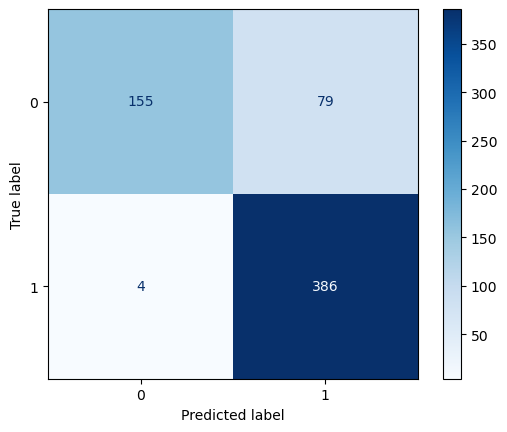

In [115]:
#Make predictions
threshold = 0.5
y_pred = (DN_model.predict(X_test) >= threshold).astype(int)

#make a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Test set results for Densenet121
recall = 99%

precision = 83%

specificity = 66%

accuracy = 87%

# Test the Densenet model on completely unseen data

In [177]:
#Read in Validation set and test model on completely unseen data
X_val_norm_images, X_val_sick_images = read_image_data(dataset='val')
#resize images
X_val_norm_resize, X_val_sick_resize = map(resize_images,[X_val_norm_images, X_val_sick_images])
#convert to numpy arrays
X_val_norm_np, X_val_sick_np = map(np.array,[X_val_norm_resize, X_val_sick_resize])
#Concatenate into X_val
X_val = np.concatenate( (X_val_norm_np , X_val_sick_np) )
#Form y_val
y_val = np.concatenate( (np.zeros((len(X_val_norm_np),)) , np.ones((len(X_val_sick_np),))) )
#Add channel dimension to image data
X_val = np.expand_dims(X_val, axis=-1)


In [178]:
#Make predictions
threshold = 0.5
y_pred = (DN_model.predict(X_val) >= threshold).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


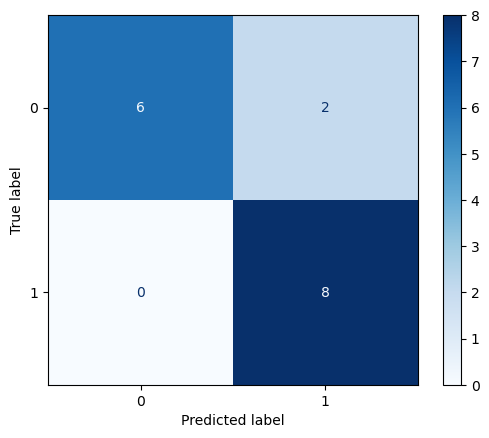

In [179]:
#make a confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()


For this small validation set, we achieve 0 false negatives (recall=100%) and 2 false positives

Finally, let's use Grad-CAM to see where our model is looking to make its decisions. We will generate a heat map to highlight the regions of the x-rays that the model focussed on

In [123]:
# Find the base model (usually the 2nd layer in your DN_model)
base = DN_model.get_layer("densenet121") 

# Print the last 5 layers to find the name of the final Conv or ReLU layer
for layer in base.layers[-5:]:
    print(layer.name)

conv5_block16_1_relu
conv5_block16_2_conv
conv5_block16_concat
bn
relu


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


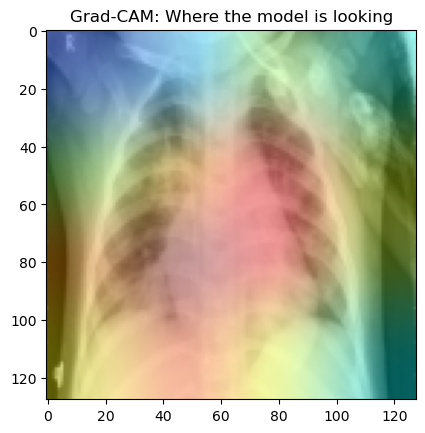

In [173]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    #Convert grayscale (1 channel) to RGB (3 channels) for DenseNet
    if img_array.shape[-1] == 1:
        img_array = tf.image.grayscale_to_rgb(tf.convert_to_tensor(img_array))

    #Extract the base model and its internal target layer
    base_model = model.get_layer("densenet121")
    target_layer = base_model.get_layer(last_conv_layer_name)
    
    # 3. BUILD A NEW FLAT MODEL
    # We bypass the 'Sequential' wrapper by using base_model.input directly.
    # To get the final prediction, we must pass the base_model output through 
    # the remaining layers of the DN_model.
    
    # Define the inputs
    inputs = base_model.input
    
    # Define the outputs: target conv layer + the final prediction
    # We manually re-link the base output to the top layers
    x = base_model.output
    # Iterate through layers in DN_model that come AFTER the densenet121 block
    found_base = False
    for layer in model.layers:
        if found_base:
            x = layer(x)
        if layer.name == "densenet121":
            found_base = True
            
    grad_model = tf.keras.models.Model(inputs, [target_layer.output, x])
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    # 1. Ensure original image is in 0-255 range and RGB
    if np.max(img) <= 1.0:
        img = img * 255
    img = np.uint8(img)
    
    # If grayscale, convert to RGB so we can see colors
    if len(img.shape) == 2 or img.shape[2] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # 2. Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # 3. Use jet colormap
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # 4. Resize heatmap to match original image size
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # 5. Superimpose: The key is ensuring both are uint8 or float in the same range
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    
    return superimposed_img

# Force the model to build by passing a dummy batch through it
DN_model.predict(np.zeros((1, 128, 128, 1)))

#ALSO ensure the internal base model is built
base_model = DN_model.get_layer("densenet121")
base_model.predict(np.zeros((1, 128, 128, 3))) # Note: DenseNet usually expects 3 channels

# --- EXECUTION ---
# Pick an image from your test set
img_sample = np.expand_dims(X_train[-4], axis=0) # Ensure batch dimension
heatmap = make_gradcam_heatmap(img_sample, DN_model, "conv5_block16_concat") # Use base model layer name
final_img = display_gradcam(img_sample[0], heatmap)

plt.imshow(final_img)
plt.title("Grad-CAM: Where the model is looking")
plt.show()

For an example Pneumonia case, we can see from the regions highlighted in red, that the model is looking generally in the region of the lungs to make its classification